<a href="https://colab.research.google.com/github/toche7/SlideAdvanceDSBDI/blob/main/notebook/BankMarketing.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Lab2: Bank Marketing

In [2]:
pip install ucimlrepo

In [3]:
from ucimlrepo import fetch_ucirepo

# fetch dataset
bank_marketing = fetch_ucirepo(id=222)

# data (as pandas dataframes)
X = bank_marketing.data.features
y = bank_marketing.data.targets

# metadata
print(bank_marketing.metadata)

# variable information
print(bank_marketing.variables)


{'uci_id': 222, 'name': 'Bank Marketing', 'repository_url': 'https://archive.ics.uci.edu/dataset/222/bank+marketing', 'data_url': 'https://archive.ics.uci.edu/static/public/222/data.csv', 'abstract': 'The data is related with direct marketing campaigns (phone calls) of a Portuguese banking institution. The classification goal is to predict if the client will subscribe a term deposit (variable y).', 'area': 'Business', 'tasks': ['Classification'], 'characteristics': ['Multivariate'], 'num_instances': 45211, 'num_features': 16, 'feature_types': ['Categorical', 'Integer'], 'demographics': ['Age', 'Occupation', 'Marital Status', 'Education Level'], 'target_col': ['y'], 'index_col': None, 'has_missing_values': 'yes', 'missing_values_symbol': 'NaN', 'year_of_dataset_creation': 2014, 'last_updated': 'Fri Aug 18 2023', 'dataset_doi': '10.24432/C5K306', 'creators': ['S. Moro', 'P. Rita', 'P. Cortez'], 'intro_paper': {'ID': 277, 'type': 'NATIVE', 'title': 'A data-driven approach to predict the s

In [4]:
type(X)

pandas.core.frame.DataFrame

In [5]:
type(y)

pandas.core.frame.DataFrame

In [8]:
import pandas as pd
df = pd.concat([X, y], axis=1)
print(df.head())

   age           job  marital  education default  balance housing loan  \
0   58    management  married   tertiary      no     2143     yes   no   
1   44    technician   single  secondary      no       29     yes   no   
2   33  entrepreneur  married  secondary      no        2     yes  yes   
3   47   blue-collar  married        NaN      no     1506     yes   no   
4   33           NaN   single        NaN      no        1      no   no   

  contact  day_of_week month  duration  campaign  pdays  previous poutcome   y  
0     NaN            5   may       261         1     -1         0      NaN  no  
1     NaN            5   may       151         1     -1         0      NaN  no  
2     NaN            5   may        76         1     -1         0      NaN  no  
3     NaN            5   may        92         1     -1         0      NaN  no  
4     NaN            5   may       198         1     -1         0      NaN  no  


In [10]:
print('Missing values before handling:')
print(df.isnull().sum())

Missing values before handling:
age                0
job              288
marital            0
education       1857
default            0
balance            0
housing            0
loan               0
contact        13020
day_of_week        0
month              0
duration           0
campaign           0
pdays              0
previous           0
poutcome       36959
y                  0
dtype: int64


In [11]:
print('\nPercentage of missing values:')
print(df.isnull().sum() * 100 / len(df))


Percentage of missing values:
age             0.000000
job             0.637013
marital         0.000000
education       4.107407
default         0.000000
balance         0.000000
housing         0.000000
loan            0.000000
contact        28.798301
day_of_week     0.000000
month           0.000000
duration        0.000000
campaign        0.000000
pdays           0.000000
previous        0.000000
poutcome       81.747805
y               0.000000
dtype: float64


In [12]:
# Drop columns 'poutcome' and 'contact' due to high percentage of missing values
df = df.drop(['poutcome', 'contact'], axis=1)
print('Columns after dropping: ')
print(df.columns)

Columns after dropping: 
Index(['age', 'job', 'marital', 'education', 'default', 'balance', 'housing',
       'loan', 'day_of_week', 'month', 'duration', 'campaign', 'pdays',
       'previous', 'y'],
      dtype='object')


In [14]:
# Impute missing values in 'job' and 'education' with their mode
df['job'] = df['job'].fillna(df['job'].mode()[0])
df['education'] = df['education'].fillna(df['education'].mode()[0])

print('\nMissing values after handling:')
print(df.isnull().sum())


Missing values after handling:
age            0
job            0
marital        0
education      0
default        0
balance        0
housing        0
loan           0
day_of_week    0
month          0
duration       0
campaign       0
pdays          0
previous       0
y              0
dtype: int64


In [15]:
print('DataFrame info after missing value handling:')
df.info()

DataFrame info after missing value handling:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 45211 entries, 0 to 45210
Data columns (total 15 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   age          45211 non-null  int64 
 1   job          45211 non-null  object
 2   marital      45211 non-null  object
 3   education    45211 non-null  object
 4   default      45211 non-null  object
 5   balance      45211 non-null  int64 
 6   housing      45211 non-null  object
 7   loan         45211 non-null  object
 8   day_of_week  45211 non-null  int64 
 9   month        45211 non-null  object
 10  duration     45211 non-null  int64 
 11  campaign     45211 non-null  int64 
 12  pdays        45211 non-null  int64 
 13  previous     45211 non-null  int64 
 14  y            45211 non-null  object
dtypes: int64(7), object(8)
memory usage: 5.2+ MB


### One-Hot Encoding for Categorical Features

Now that missing values are handled, we need to convert categorical features into a numerical format that machine learning algorithms can understand. We'll use one-hot encoding for this, creating new binary columns for each category and dropping the original categorical columns.

In [21]:
# Identify categorical columns to encode
categorical_cols = df.select_dtypes(include='object').columns.tolist()

# Exclude the target variable 'y' from one-hot encoding if it's in the list
if 'y' in categorical_cols:
    categorical_cols.remove('y')

# Apply one-hot encoding using pd.get_dummies
# drop_first=True avoids multicollinearity by dropping the first category of each feature
df_encoded = pd.get_dummies(df, columns=categorical_cols, drop_first=True)

print('DataFrame head after one-hot encoding:')
display(df_encoded.head())
print('\nDataFrame info after one-hot encoding:')
df_encoded.info()

DataFrame head after one-hot encoding:


,age,balance,day_of_week,duration,campaign,pdays,previous,y,job_blue-collar,job_entrepreneur,...,month_dec,month_feb,month_jan,month_jul,month_jun,month_mar,month_may,month_nov,month_oct,month_sep
0,58,2143,5,261,1,-1,0,no,False,False,...,False,False,False,False,False,False,True,False,False,False
1,44,29,5,151,1,-1,0,no,False,False,...,False,False,False,False,False,False,True,False,False,False
2,33,2,5,76,1,-1,0,no,False,True,...,False,False,False,False,False,False,True,False,False,False
3,47,1506,5,92,1,-1,0,no,True,False,...,False,False,False,False,False,False,True,False,False,False
4,33,1,5,198,1,-1,0,no,True,False,...,False,False,False,False,False,False,True,False,False,False



DataFrame info after one-hot encoding:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 45211 entries, 0 to 45210
Data columns (total 36 columns):
 #   Column               Non-Null Count  Dtype 
---  ------               --------------  ----- 
 0   age                  45211 non-null  int64 
 1   balance              45211 non-null  int64 
 2   day_of_week          45211 non-null  int64 
 3   duration             45211 non-null  int64 
 4   campaign             45211 non-null  int64 
 5   pdays                45211 non-null  int64 
 6   previous             45211 non-null  int64 
 7   y                    45211 non-null  object
 8   job_blue-collar      45211 non-null  bool  
 9   job_entrepreneur     45211 non-null  bool  
 10  job_housemaid        45211 non-null  bool  
 11  job_management       45211 non-null  bool  
 12  job_retired          45211 non-null  bool  
 13  job_self-employed    45211 non-null  bool  
 14  job_services         45211 non-null  bool  
 15  job_student  

### Separate Features (X) and Target (y)

After encoding, we separate our dataset into features (`X`) and the target variable (`y_yes`), which represents whether the client subscribed to a term deposit. This is a standard step before training a machine learning model.

In [22]:
# Separate features (X) and target (y)
X = df_encoded.drop('y', axis=1)
y = df_encoded['y']

# Convert the target variable 'y' into a numerical format (0 or 1)
y = y.map({'no': 0, 'yes': 1})

print(f'Shape of X: {X.shape}')
print(f'Shape of y: {y.shape}')
print('\nFirst 5 rows of X:')
display(X.head())
print('\nFirst 5 rows of y:')
display(y.head())

Shape of X: (45211, 35)
Shape of y: (45211,)

First 5 rows of X:


,age,balance,day_of_week,duration,campaign,pdays,previous,job_blue-collar,job_entrepreneur,job_housemaid,...,month_dec,month_feb,month_jan,month_jul,month_jun,month_mar,month_may,month_nov,month_oct,month_sep
0,58,2143,5,261,1,-1,0,False,False,False,...,False,False,False,False,False,False,True,False,False,False
1,44,29,5,151,1,-1,0,False,False,False,...,False,False,False,False,False,False,True,False,False,False
2,33,2,5,76,1,-1,0,False,True,False,...,False,False,False,False,False,False,True,False,False,False
3,47,1506,5,92,1,-1,0,True,False,False,...,False,False,False,False,False,False,True,False,False,False
4,33,1,5,198,1,-1,0,True,False,False,...,False,False,False,False,False,False,True,False,False,False



First 5 rows of y:


,y
0,0
1,0
2,0
3,0
4,0


### Split Data into Training and Testing Sets

To prepare for model training and evaluation, we'll split our `X` (features) and `y` (target) data into training and testing sets. A common split is 80% for training and 20% for testing. We'll also use `stratify=y` to ensure that the proportion of target classes is maintained in both the training and testing sets, which is important for imbalanced datasets.

In [23]:
from sklearn.model_selection import train_test_split

# Split the data into training and testing sets
# test_size=0.2 means 20% of the data will be used for testing
# random_state=42 ensures reproducibility
# stratify=y ensures that the proportion of 'yes' and 'no' in the target variable is the same in both train and test sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print(f'Shape of X_train: {X_train.shape}')
print(f'Shape of X_test: {X_test.shape}')
print(f'Shape of y_train: {y_train.shape}')
print(f'Shape of y_test: {y_test.shape}')

Shape of X_train: (36168, 35)
Shape of X_test: (9043, 35)
Shape of y_train: (36168,)
Shape of y_test: (9043,)


### Feature Scaling

Many machine learning algorithms perform better when numerical input variables are scaled to a standard range. We'll use `StandardScaler` to transform our numerical features so that they have a mean of 0 and a standard deviation of 1. It's important to fit the scaler only on the training data (`X_train`) to prevent data leakage from the test set, and then use that fitted scaler to transform both `X_train` and `X_test`.

In [24]:
from sklearn.preprocessing import StandardScaler

# Identify numerical columns for scaling
# These are the columns that are not boolean (from one-hot encoding)
numerical_cols = X_train.select_dtypes(include=['int64', 'float64']).columns

# Initialize the StandardScaler
scaler = StandardScaler()

# Fit the scaler on the training data and transform both training and testing data
X_train[numerical_cols] = scaler.fit_transform(X_train[numerical_cols])
X_test[numerical_cols] = scaler.transform(X_test[numerical_cols])

print('First 5 rows of X_train after scaling:')
display(X_train.head())

print('\nFirst 5 rows of X_test after scaling:')
display(X_test.head())

First 5 rows of X_train after scaling:


,age,balance,day_of_week,duration,campaign,pdays,previous,job_blue-collar,job_entrepreneur,job_housemaid,...,month_dec,month_feb,month_jan,month_jul,month_jun,month_mar,month_may,month_nov,month_oct,month_sep
24001,-0.460434,-0.164410,1.582124,-0.457311,-0.246104,-0.410910,-0.241509,False,False,False,...,False,False,False,False,False,False,False,False,False,False
43409,-1.589641,0.899627,-1.298384,2.502493,0.398202,1.446096,2.664584,False,False,False,...,False,False,False,False,False,False,False,False,False,False
20669,0.292371,-0.365486,-0.458236,5.697691,0.398202,-0.410910,-0.241509,False,False,False,...,False,False,False,False,False,False,False,False,False,False
18810,0.668773,-0.445003,1.822166,-0.862499,2.653271,-0.410910,-0.241509,False,False,False,...,False,False,False,True,False,False,False,False,False,False
23130,-0.272233,-0.361249,1.222060,-0.777602,2.331118,-0.410910,-0.241509,False,False,False,...,False,False,False,False,False,False,False,False,False,False



First 5 rows of X_test after scaling:


,age,balance,day_of_week,duration,campaign,pdays,previous,job_blue-collar,job_entrepreneur,job_housemaid,...,month_dec,month_feb,month_jan,month_jul,month_jun,month_mar,month_may,month_nov,month_oct,month_sep
1392,-0.084032,-0.236433,-0.938321,0.341489,-0.246104,-0.41091,-0.241509,True,False,False,...,False,False,False,False,False,False,True,False,False,False
7518,0.292371,-0.321816,1.702145,-0.214198,-0.246104,-0.41091,-0.241509,False,False,False,...,False,False,False,False,False,False,True,False,False,False
12007,-0.930937,-0.328986,0.501933,-0.117724,0.720354,-0.41091,-0.241509,False,False,False,...,False,False,False,False,True,False,False,False,False,False
5536,-0.460434,-0.231544,0.861997,-0.407144,0.398202,-0.41091,-0.241509,True,False,False,...,False,False,False,False,False,False,True,False,False,False
29816,-0.648635,0.181035,-1.418405,-0.762166,-0.568256,-0.41091,-0.241509,False,False,False,...,False,True,False,False,False,False,False,False,False,False


### Train a Logistic Regression Model

With the data now preprocessed, we can train a machine learning model. Logistic Regression is a good baseline model for binary classification. We'll train the model on our `X_train` and `y_train` sets.

In [25]:
from sklearn.linear_model import LogisticRegression

# Initialize the Logistic Regression model
log_reg_model = LogisticRegression(random_state=42, solver='liblinear') # 'liblinear' is a good choice for smaller datasets or when using L1/L2 regularization

# Train the model using the scaled training data
log_reg_model.fit(X_train, y_train)

print("Logistic Regression model trained successfully!")

Logistic Regression model trained successfully!


### Evaluate the Logistic Regression Model

After training, we need to evaluate the model's performance on the test set to see how well it generalizes to new, unseen data. We'll use common classification metrics such as accuracy, precision, recall, and F1-score, and visualize the results with a confusion matrix and a classification report.

Accuracy: 0.8922
Precision: 0.5912
Recall: 0.2543
F1-Score: 0.3556

Classification Report:
              precision    recall  f1-score   support

           0       0.91      0.98      0.94      7985
           1       0.59      0.25      0.36      1058

    accuracy                           0.89      9043
   macro avg       0.75      0.62      0.65      9043
weighted avg       0.87      0.89      0.87      9043



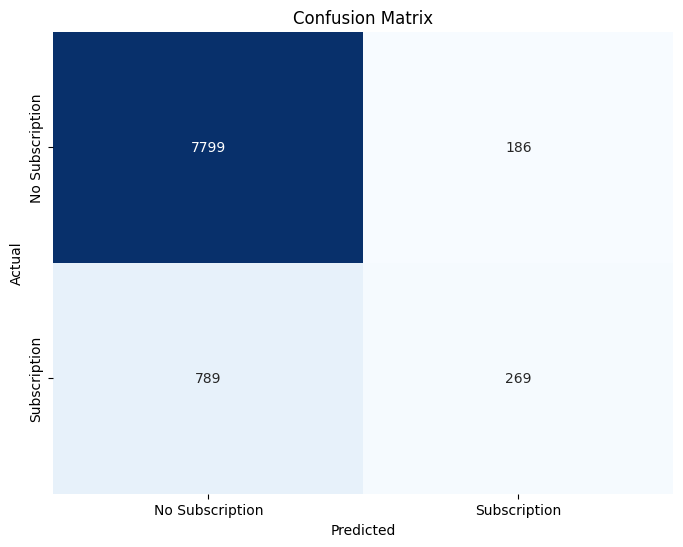

In [26]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report
import matplotlib.pyplot as plt
import seaborn as sns

# Make predictions on the scaled test data
y_pred = log_reg_model.predict(X_test)

# Calculate evaluation metrics
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

print(f'Accuracy: {accuracy:.4f}')
print(f'Precision: {precision:.4f}')
print(f'Recall: {recall:.4f}')
print(f'F1-Score: {f1:.4f}')

# Display classification report
print('\nClassification Report:')
print(classification_report(y_test, y_pred))

# Display confusion matrix
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False,
            xticklabels=['No Subscription', 'Subscription'],
            yticklabels=['No Subscription', 'Subscription'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()

### Handle Class Imbalance with SMOTE

Looking at the classification report, the recall for the 'Subscription' class (class 1) is quite low (0.2543). This indicates that the model is not very good at identifying customers who *will* subscribe to a term deposit. This is a common issue in imbalanced datasets where the minority class has significantly fewer samples than the majority class. To address this, we will use **SMOTE (Synthetic Minority Over-sampling Technique)** on the training data (`X_train`, `y_train`) to create synthetic samples of the minority class, thereby balancing the dataset.

In [27]:
from imblearn.over_sampling import SMOTE

# Initialize SMOTE
smote = SMOTE(random_state=42)

# Apply SMOTE to the training data
X_train_smote, y_train_smote = smote.fit_resample(X_train, y_train)

print(f'Shape of X_train before SMOTE: {X_train.shape}')
print(f'Shape of X_train after SMOTE: {X_train_smote.shape}')
print(f'Count of y_train before SMOTE:\n{y_train.value_counts()}')
print(f'Count of y_train after SMOTE:\n{y_train_smote.value_counts()}')

Shape of X_train before SMOTE: (36168, 35)
Shape of X_train after SMOTE: (63874, 35)
Count of y_train before SMOTE:
y
0    31937
1     4231
Name: count, dtype: int64
Count of y_train after SMOTE:
y
0    31937
1    31937
Name: count, dtype: int64


### Retrain Logistic Regression Model with SMOTE-balanced Data

Now that the training data is balanced using SMOTE, we will retrain the Logistic Regression model using this new, balanced dataset. We expect to see an improvement in the model's ability to predict the minority class.

In [28]:
# Initialize a new Logistic Regression model (or re-use the previous one)
log_reg_model_smote = LogisticRegression(random_state=42, solver='liblinear')

# Train the model using the SMOTE-balanced training data
log_reg_model_smote.fit(X_train_smote, y_train_smote)

print("Logistic Regression model retrained successfully with SMOTE data!")

Logistic Regression model retrained successfully with SMOTE data!


### Re-evaluate the Model Performance

Let's re-evaluate the performance of the retrained Logistic Regression model on the original (unbalanced) test set (`X_test`, `y_test`). This will show us if SMOTE helped improve the model's ability to generalize and predict the minority class.

Accuracy (after SMOTE): 0.8319
Precision (after SMOTE): 0.3829
Recall (after SMOTE): 0.7136
F1-Score (after SMOTE): 0.4983

Classification Report (after SMOTE):
              precision    recall  f1-score   support

           0       0.96      0.85      0.90      7985
           1       0.38      0.71      0.50      1058

    accuracy                           0.83      9043
   macro avg       0.67      0.78      0.70      9043
weighted avg       0.89      0.83      0.85      9043



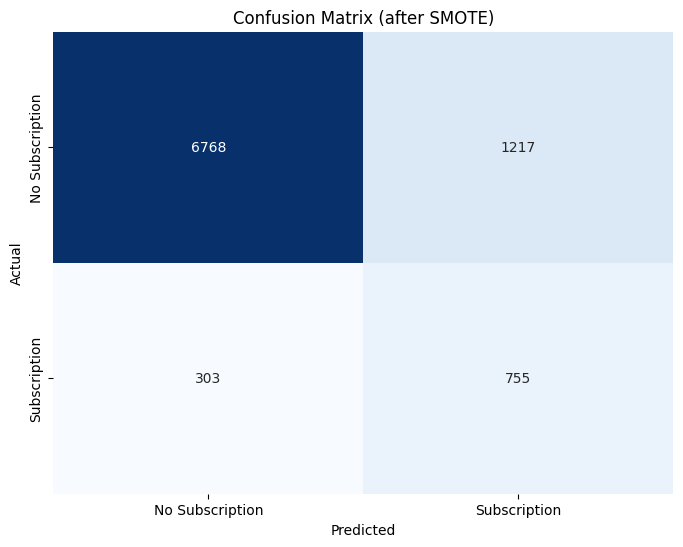

In [29]:
# Make predictions on the original scaled test data using the SMOTE-trained model
y_pred_smote = log_reg_model_smote.predict(X_test)

# Calculate evaluation metrics
accuracy_smote = accuracy_score(y_test, y_pred_smote)
precision_smote = precision_score(y_test, y_pred_smote)
recall_smote = recall_score(y_test, y_pred_smote)
f1_smote = f1_score(y_test, y_pred_smote)

print(f'Accuracy (after SMOTE): {accuracy_smote:.4f}')
print(f'Precision (after SMOTE): {precision_smote:.4f}')
print(f'Recall (after SMOTE): {recall_smote:.4f}')
print(f'F1-Score (after SMOTE): {f1_smote:.4f}')

# Display classification report
print('\nClassification Report (after SMOTE):')
print(classification_report(y_test, y_pred_smote))

# Display confusion matrix
cm_smote = confusion_matrix(y_test, y_pred_smote)
plt.figure(figsize=(8, 6))
sns.heatmap(cm_smote, annot=True, fmt='d', cmap='Blues', cbar=False,
            xticklabels=['No Subscription', 'Subscription'],
            yticklabels=['No Subscription', 'Subscription'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix (after SMOTE)')
plt.show()

### Train a Support Vector Machine (SVM) Model with SMOTE-balanced Data

Support Vector Machines (SVMs) are powerful and versatile machine learning models capable of performing linear or non-linear classification, regression, and even outlier detection. We'll train an SVM classifier on the SMOTE-balanced training data. Due to the computational cost of SVMs on larger datasets, we will use a linear kernel for this initial attempt.

In [33]:
from sklearn.svm import SVC

# Initialize the SVM model (using a linear kernel for efficiency on larger datasets)
# class_weight='balanced' can help manage class imbalance here as well
svm_model = SVC(kernel='linear', random_state=42, class_weight='balanced')

# Train the model using the SMOTE-balanced training data
print("Starting SVM model training...")
svm_model.fit(X_train_smote, y_train_smote)

print("SVM model trained successfully with SMOTE data!")

Starting SVM model training...
SVM model trained successfully with SMOTE data!


### Evaluate the SVM Model Performance

Let's evaluate the performance of the trained SVM model on the original (unbalanced) test set (`X_test`, `y_test`) and compare its metrics with the previous models.

Accuracy (SVM): 0.8279
Precision (SVM): 0.3766
Recall (SVM): 0.7183
F1-Score (SVM): 0.4941

Classification Report (SVM):
              precision    recall  f1-score   support

           0       0.96      0.84      0.90      7985
           1       0.38      0.72      0.49      1058

    accuracy                           0.83      9043
   macro avg       0.67      0.78      0.70      9043
weighted avg       0.89      0.83      0.85      9043



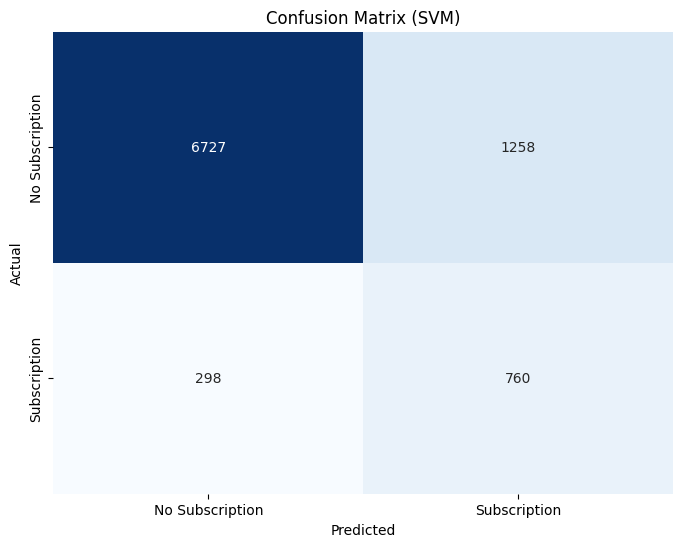

In [34]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report
import matplotlib.pyplot as plt
import seaborn as sns

# Make predictions on the original scaled test data using the SVM model
y_pred_svm = svm_model.predict(X_test)

# Calculate evaluation metrics
accuracy_svm = accuracy_score(y_test, y_pred_svm)
precision_svm = precision_score(y_test, y_pred_svm)
recall_svm = recall_score(y_test, y_pred_svm)
f1_svm = f1_score(y_test, y_pred_svm)

print(f'Accuracy (SVM): {accuracy_svm:.4f}')
print(f'Precision (SVM): {precision_svm:.4f}')
print(f'Recall (SVM): {recall_svm:.4f}')
print(f'F1-Score (SVM): {f1_svm:.4f}')

# Display classification report
print('\nClassification Report (SVM):')
print(classification_report(y_test, y_pred_svm))

# Display confusion matrix
cm_svm = confusion_matrix(y_test, y_pred_svm)
plt.figure(figsize=(8, 6))
sns.heatmap(cm_svm, annot=True, fmt='d', cmap='Blues', cbar=False,
            xticklabels=['No Subscription', 'Subscription'],
            yticklabels=['No Subscription', 'Subscription'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix (SVM)')
plt.show()

### Train a Neural Network (MLPClassifier) Model with SMOTE-balanced Data

Neural Networks, specifically Multilayer Perceptrons (MLPs), are another powerful class of models for classification. We'll train a simple MLPClassifier on the SMOTE-balanced training data to see how it performs against our other models. For a basic setup, we'll use a single hidden layer.

In [35]:
from sklearn.neural_network import MLPClassifier

# Initialize the MLPClassifier model
# Using a small hidden layer for demonstration; can be tuned further
mlp_model = MLPClassifier(hidden_layer_sizes=(100,), max_iter=300, random_state=42,
                          solver='adam', early_stopping=True, validation_fraction=0.1)

# Train the model using the SMOTE-balanced training data
print("Starting Neural Network model training...")
mlp_model.fit(X_train_smote, y_train_smote)

print("Neural Network model trained successfully with SMOTE data!")

Starting Neural Network model training...
Neural Network model trained successfully with SMOTE data!


### Evaluate the Neural Network (MLPClassifier) Performance

Finally, let's evaluate the performance of the trained Neural Network model on the original (unbalanced) test set (`X_test`, `y_test`) and compare its metrics with the other models.

Accuracy (Neural Network): 0.8625
Precision (Neural Network): 0.4438
Recall (Neural Network): 0.6900
F1-Score (Neural Network): 0.5401

Classification Report (Neural Network):
              precision    recall  f1-score   support

           0       0.96      0.89      0.92      7985
           1       0.44      0.69      0.54      1058

    accuracy                           0.86      9043
   macro avg       0.70      0.79      0.73      9043
weighted avg       0.90      0.86      0.87      9043



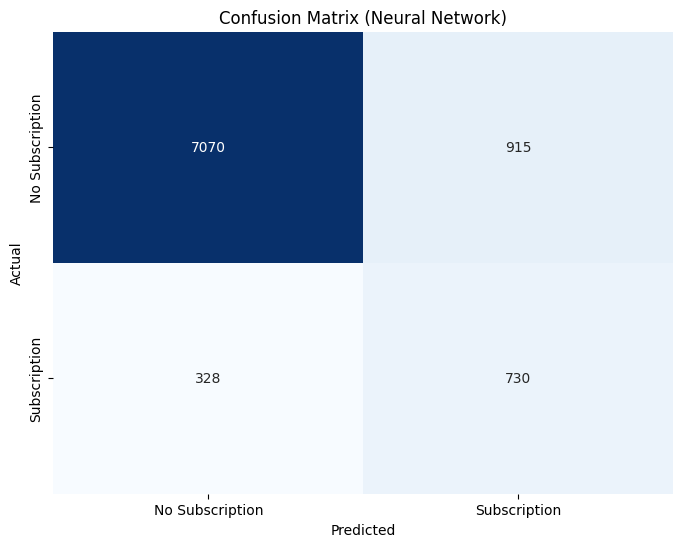

In [36]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report
import matplotlib.pyplot as plt
import seaborn as sns

# Make predictions on the original scaled test data using the MLP model
y_pred_mlp = mlp_model.predict(X_test)

# Calculate evaluation metrics
accuracy_mlp = accuracy_score(y_test, y_pred_mlp)
precision_mlp = precision_score(y_test, y_pred_mlp)
recall_mlp = recall_score(y_test, y_pred_mlp)
f1_mlp = f1_score(y_test, y_pred_mlp)

print(f'Accuracy (Neural Network): {accuracy_mlp:.4f}')
print(f'Precision (Neural Network): {precision_mlp:.4f}')
print(f'Recall (Neural Network): {recall_mlp:.4f}')
print(f'F1-Score (Neural Network): {f1_mlp:.4f}')

# Display classification report
print('\nClassification Report (Neural Network):')
print(classification_report(y_test, y_pred_mlp))

# Display confusion matrix
cm_mlp = confusion_matrix(y_test, y_pred_mlp)
plt.figure(figsize=(8, 6))
sns.heatmap(cm_mlp, annot=True, fmt='d', cmap='Blues', cbar=False,
            xticklabels=['No Subscription', 'Subscription'],
            yticklabels=['No Subscription', 'Subscription'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix (Neural Network)')
plt.show()